In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
file_path = '/kaggle/input/datasets/amaymishra11/student-placement-and-salary-dataset-skills-based/student_placement_salary_elite_v2.csv'
df = pd.read_csv(file_path)

# Preliminary data exploration
info = df.info()
head = df.head()
summary_stats = df.describe()

print("--- DataFrame Info ---")
print(info)
print("\n--- First 5 Rows ---")
print(head)
print("\n--- Summary Statistics ---")
print(summary_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   i

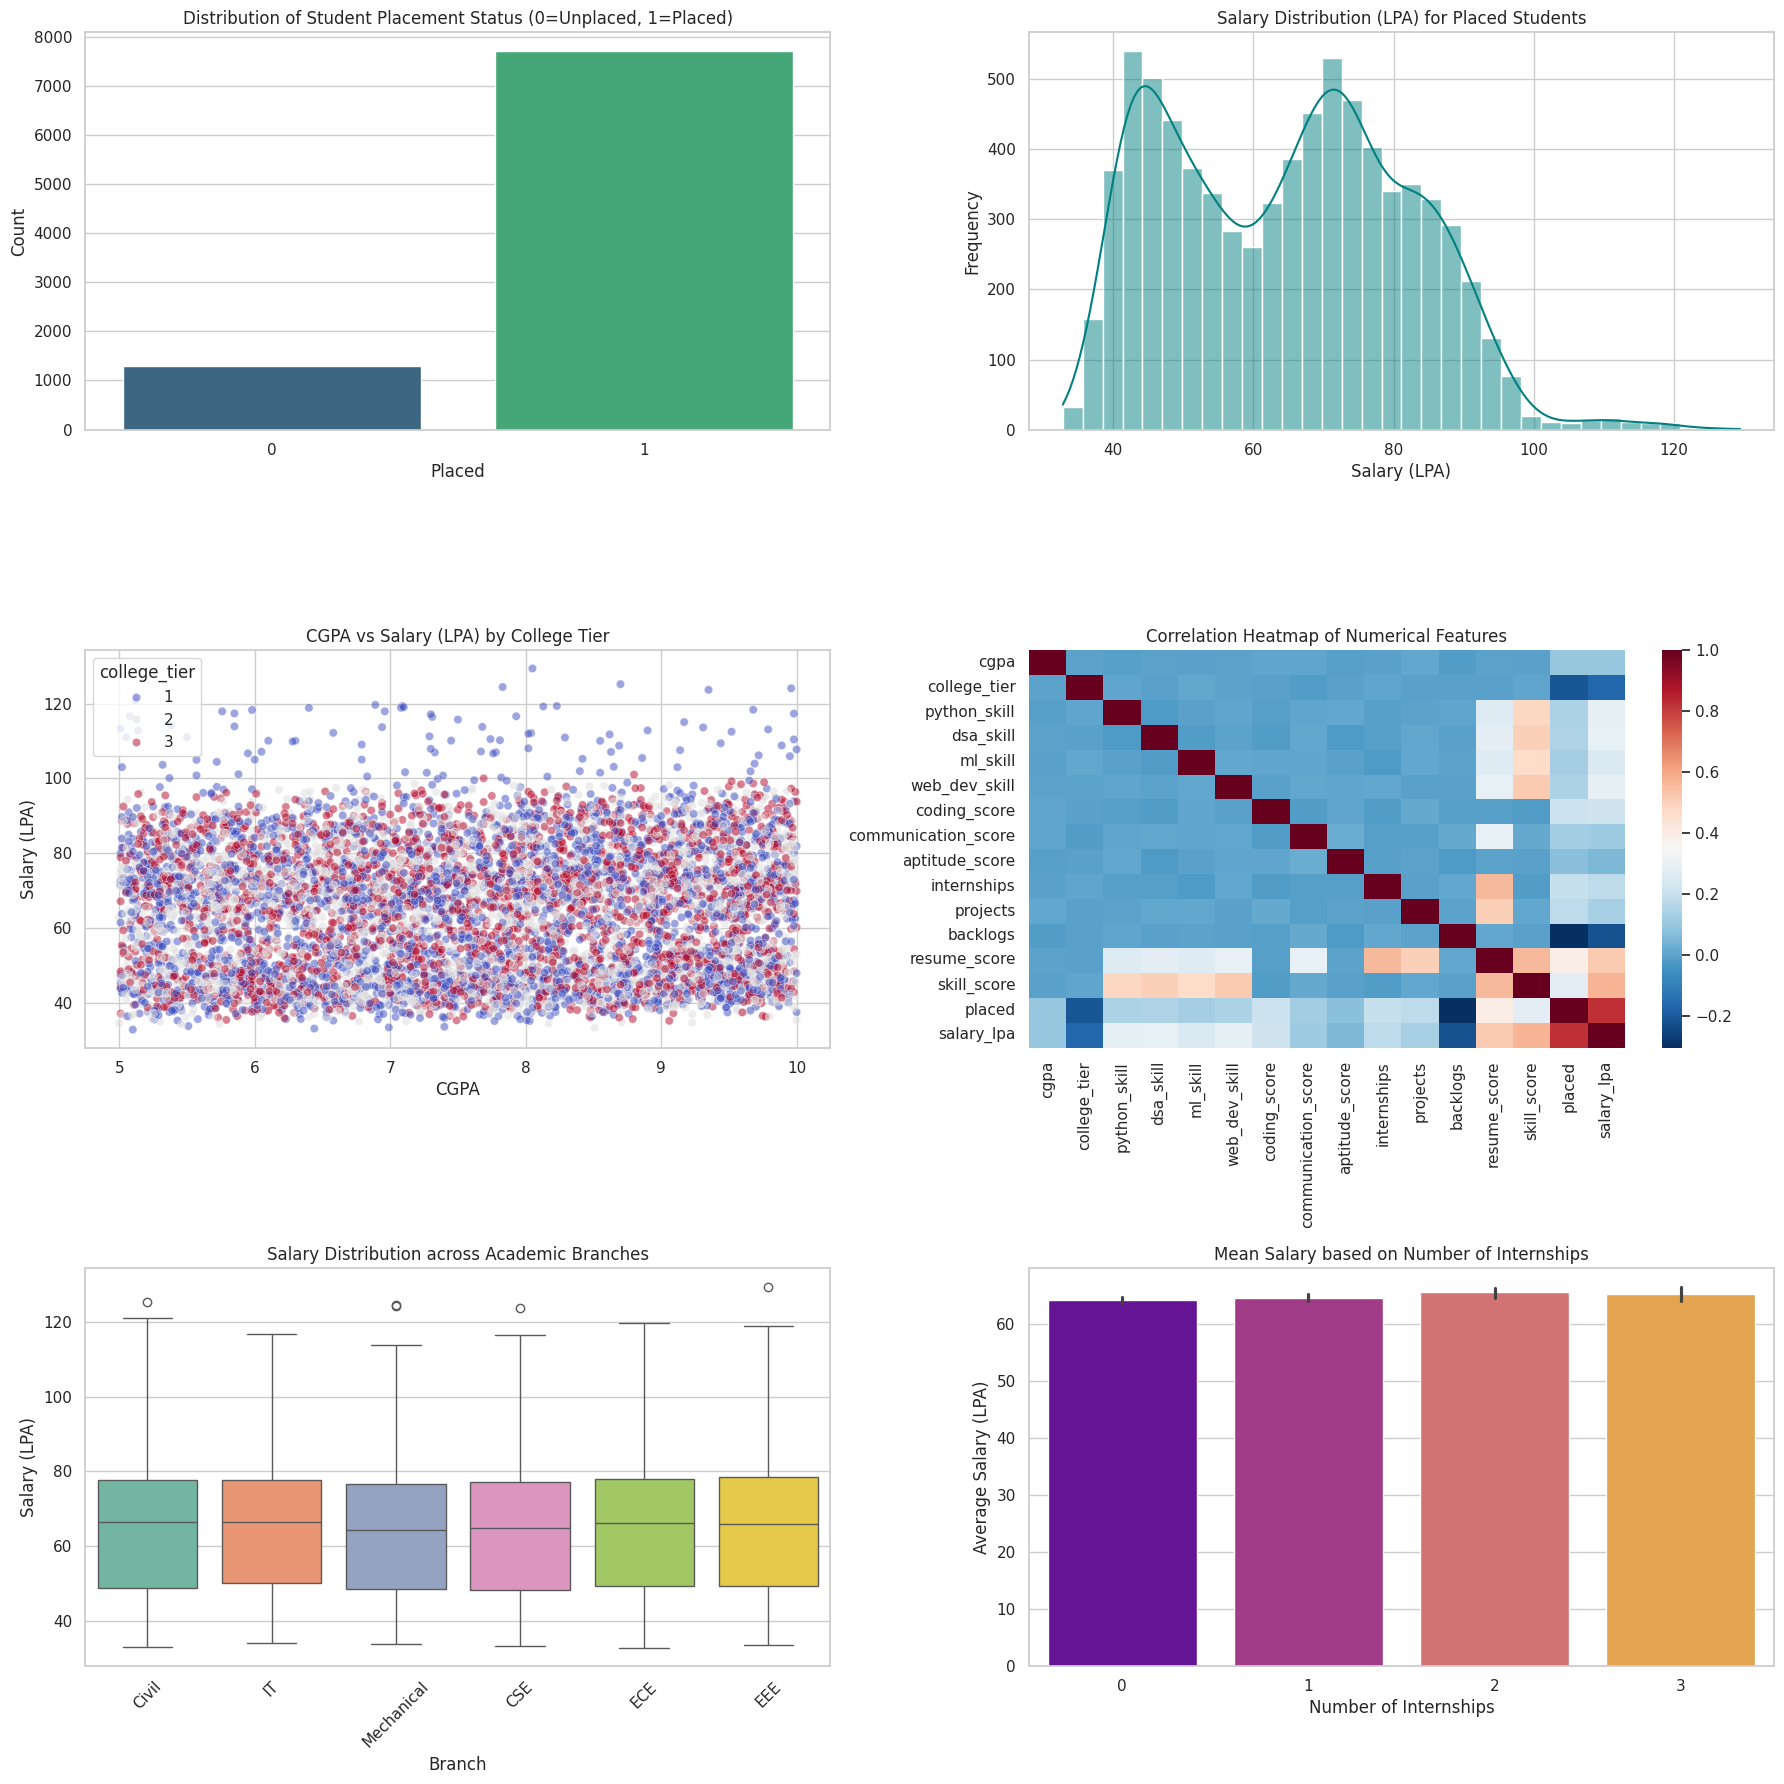

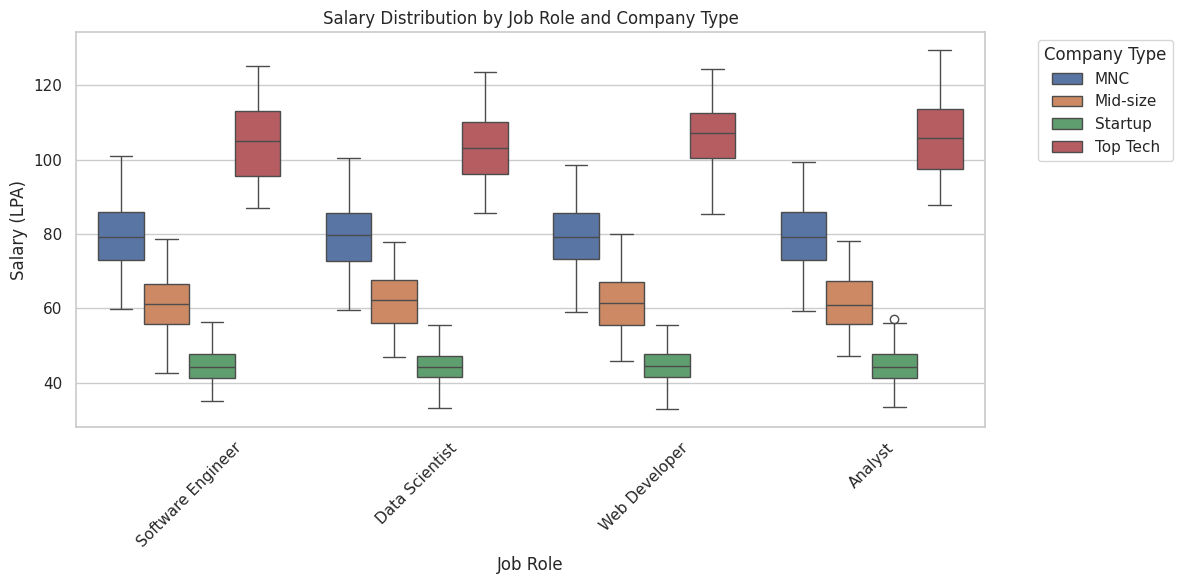

In [2]:
# Filter data for placed students for salary-related analysis
placed_df = df[df['placed'] == 1]

# Set the aesthetics
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# 1. Placement Distribution
sns.countplot(data=df, x='placed', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribution of Student Placement Status (0=Unplaced, 1=Placed)')
axes[0, 0].set_xlabel('Placed')
axes[0, 0].set_ylabel('Count')

# 2. Salary Distribution for Placed Students
sns.histplot(placed_df['salary_lpa'], kde=True, color='teal', ax=axes[0, 1])
axes[0, 1].set_title('Salary Distribution (LPA) for Placed Students')
axes[0, 1].set_xlabel('Salary (LPA)')
axes[0, 1].set_ylabel('Frequency')

# 3. CGPA vs Salary
sns.scatterplot(data=placed_df, x='cgpa', y='salary_lpa', hue='college_tier', palette='coolwarm', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('CGPA vs Salary (LPA) by College Tier')
axes[1, 0].set_xlabel('CGPA')
axes[1, 0].set_ylabel('Salary (LPA)')

# 4. Correlation Heatmap (Numerical values)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap='RdBu_r', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap of Numerical Features')

# 5. Salary by Branch
sns.boxplot(data=placed_df, x='branch', y='salary_lpa', ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('Salary Distribution across Academic Branches')
axes[2, 0].set_xlabel('Branch')
axes[2, 0].set_ylabel('Salary (LPA)')
plt.setp(axes[2, 0].get_xticklabels(), rotation=45)

# 6. Internships vs Salary
sns.barplot(data=placed_df, x='internships', y='salary_lpa', ax=axes[2, 1], palette='plasma')
axes[2, 1].set_title('Mean Salary based on Number of Internships')
axes[2, 1].set_xlabel('Number of Internships')
axes[2, 1].set_ylabel('Average Salary (LPA)')

plt.tight_layout()
plt.savefig('placement_analysis.png')
plt.show()

# Additional View: Salary by Job Role and Company Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=placed_df, x='job_role', y='salary_lpa', hue='company_type')
plt.title('Salary Distribution by Job Role and Company Type')
plt.xlabel('Job Role')
plt.ylabel('Salary (LPA)')
plt.legend(title='Company Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('job_salary_analysis.png')
plt.show()

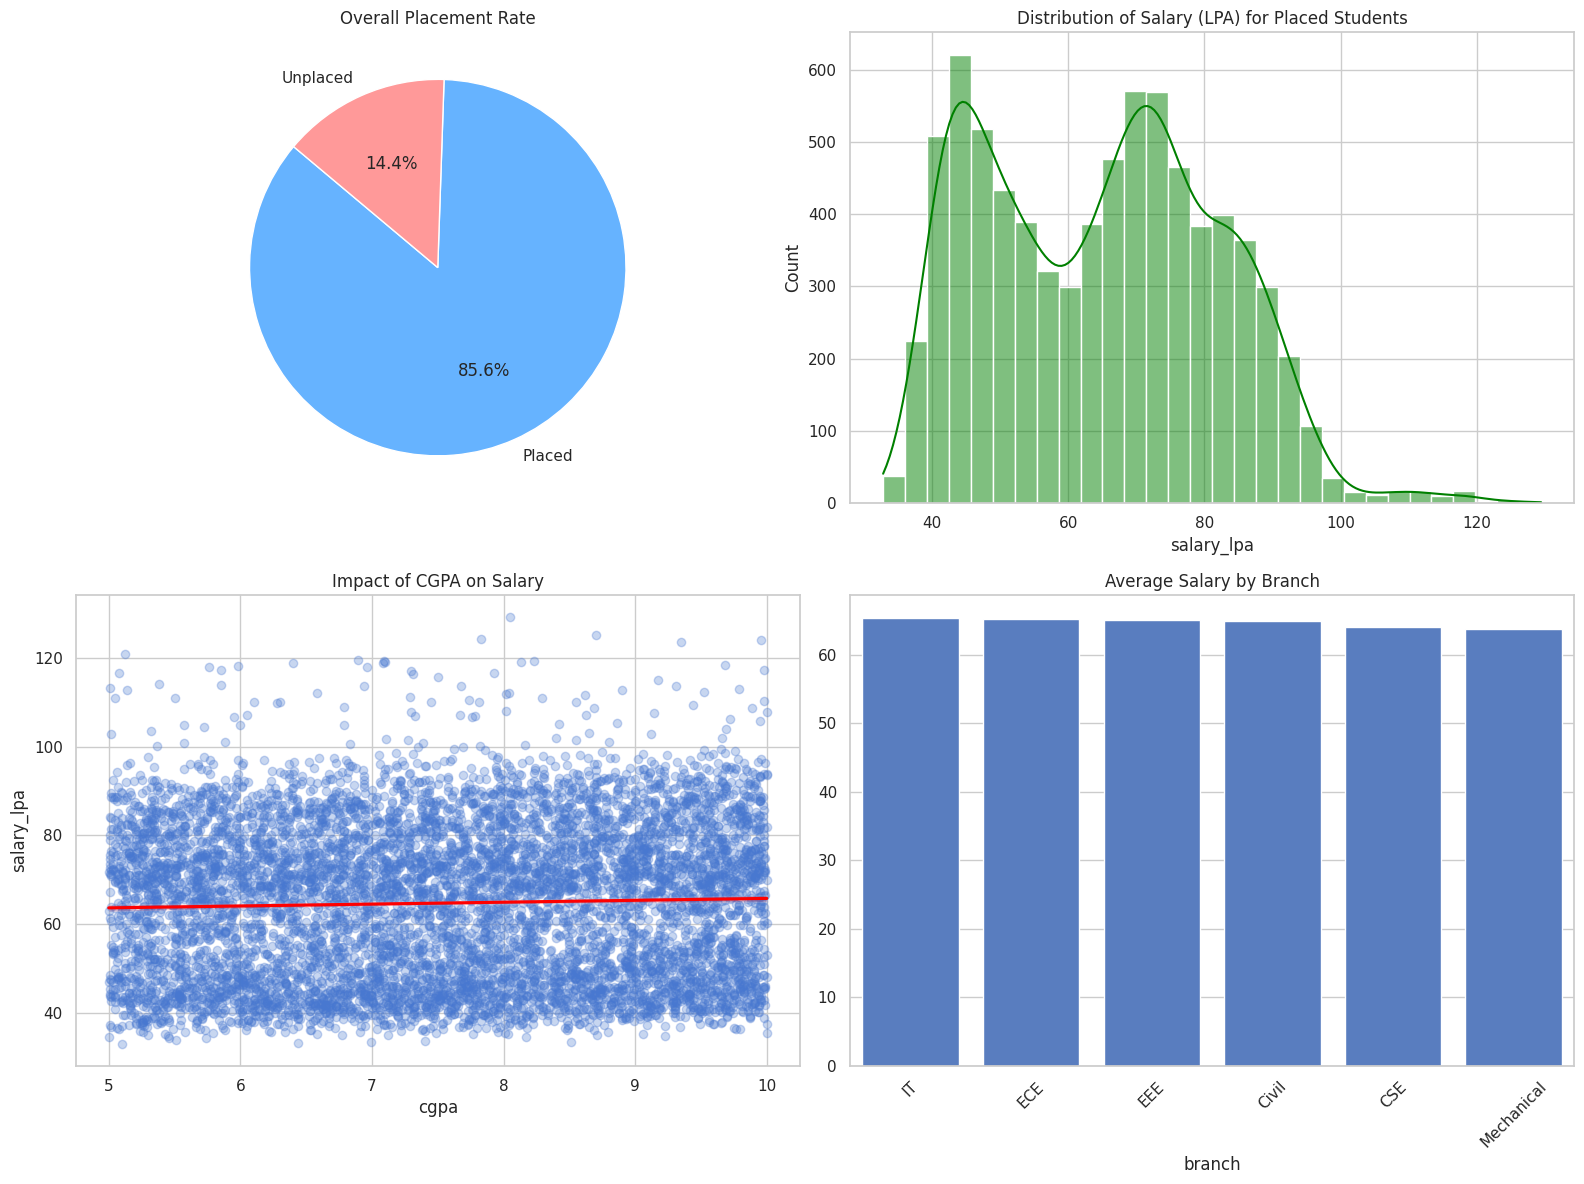

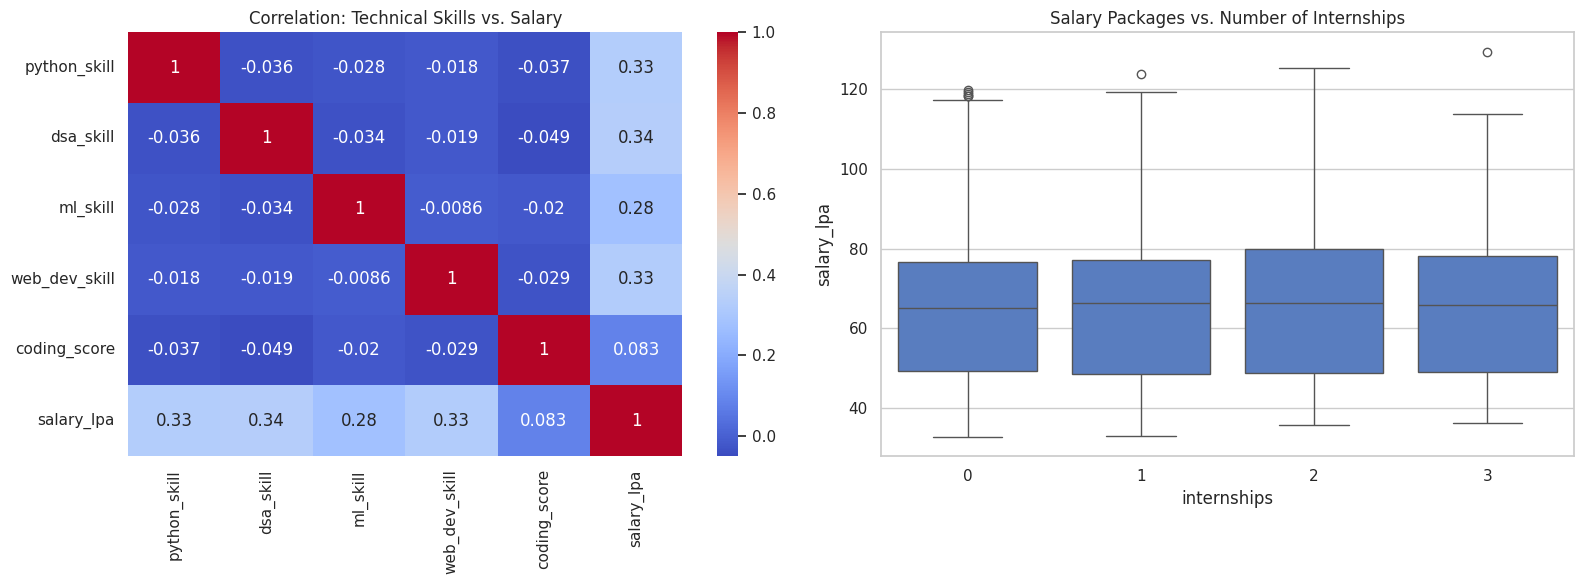

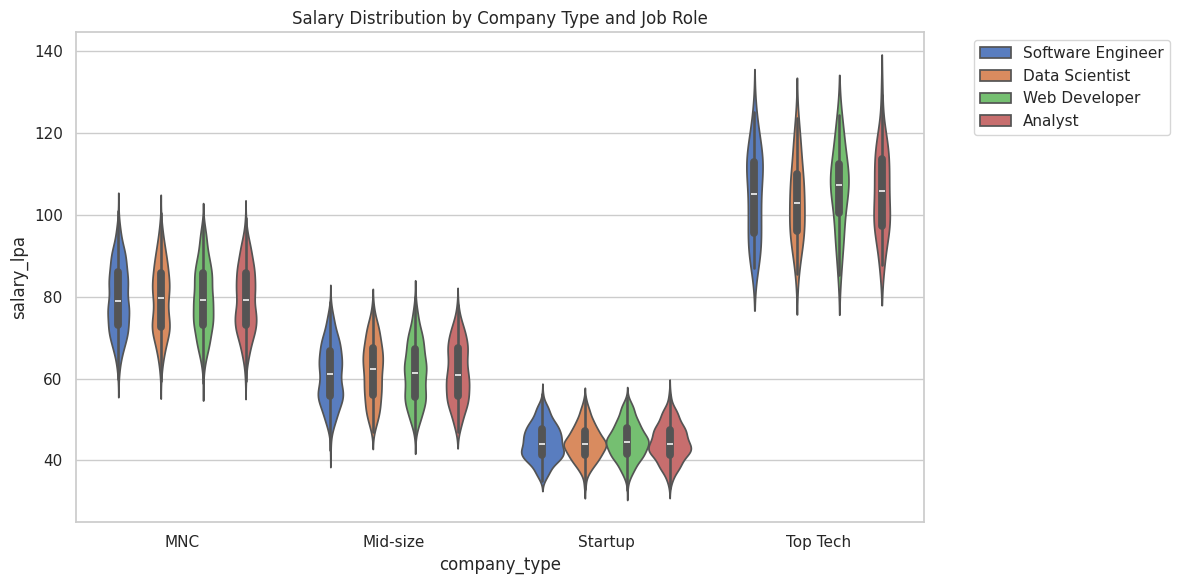

Top Average Salaries by Job Role:
job_role
Data Scientist       64.957043
Web Developer        64.773161
Analyst              64.643289
Software Engineer    64.612989
Name: salary_lpa, dtype: float64


In [3]:
# Prep data
placed_df = df[df['placed'] == 1].copy()

# Set aesthetics
sns.set_theme(style="whitegrid", palette="muted")

# 1. Dashboard Overview
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Placement Rate
placement_counts = df['placed'].value_counts()
axes[0,0].pie(placement_counts, labels=['Placed', 'Unplaced'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
axes[0,0].set_title('Overall Placement Rate')

# Subplot 2: Salary Distribution
sns.histplot(placed_df['salary_lpa'], bins=30, kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Distribution of Salary (LPA) for Placed Students')

# Subplot 3: CGPA vs Salary
sns.regplot(data=placed_df, x='cgpa', y='salary_lpa', scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1,0])
axes[1,0].set_title('Impact of CGPA on Salary')

# Subplot 4: Average Salary by Branch
branch_salary = placed_df.groupby('branch')['salary_lpa'].mean().sort_values(ascending=False)
sns.barplot(x=branch_salary.index, y=branch_salary.values, ax=axes[1,1])
axes[1,1].set_title('Average Salary by Branch')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('general_analysis.png')

# 2. Detailed Factors Analysis
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 5: Skills correlation with Salary
skills_cols = ['python_skill', 'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score', 'salary_lpa']
sns.heatmap(placed_df[skills_cols].corr(), annot=True, cmap='coolwarm', ax=axes2[0])
axes2[0].set_title('Correlation: Technical Skills vs. Salary')

# Subplot 6: Internships impact
sns.boxplot(data=placed_df, x='internships', y='salary_lpa', ax=axes2[1])
axes2[1].set_title('Salary Packages vs. Number of Internships')

plt.tight_layout()
plt.savefig('skills_internships.png')

# 3. Industry Segmentation
plt.figure(figsize=(12, 6))
sns.violinplot(data=placed_df, x='company_type', y='salary_lpa', hue='job_role', split=False)
plt.title('Salary Distribution by Company Type and Job Role')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.savefig('industry_segmentation.png')

plt.show()

# Print some key insights for the text response
top_roles = placed_df.groupby('job_role')['salary_lpa'].mean().sort_values(ascending=False)
print("Top Average Salaries by Job Role:")
print(top_roles)